# Radioactive Decay Chains

![](./images/uranium_decay.png)

Radioactive decay chains are perhaps the most natural example of a continuous-time Markov chain with an absorbing state. Each unstable isotope decays to the next via a first-order (unimolecular) process, and the chain terminates at a stable isotope — the absorbing state. The mathematics governing these chains were worked out by **Ernest Rutherford** and **Frederick Soddy** in 1902, and generalized by **Harry Bateman** in 1910, decades before Marcel Neuts formalized phase-type distributions in the 1970s.

In this notebook we model the **uranium-238 decay series** as a phase-type distribution and show how the matrix exponential $\boldsymbol{\pi} e^{\mathbf{S}t}$ recovers the classical Bateman equations. The full decay chain from ${}^{238}\text{U}$ to stable ${}^{206}\text{Pb}$ involves 14 decay steps through a series of alpha ($\alpha$) and beta ($\beta^-$) decays:

$$
{}^{238}\text{U} \xrightarrow[\alpha]{4.468 \times 10^9 \text{ yr}}
{}^{234}\text{Th} \xrightarrow[\beta^-]{24.10 \text{ d}}
{}^{234}\text{Pa} \xrightarrow[\beta^-]{1.17 \text{ min}}
{}^{234}\text{U} \xrightarrow[\alpha]{2.455 \times 10^5 \text{ yr}}
{}^{230}\text{Th} \xrightarrow[\alpha]{7.54 \times 10^4 \text{ yr}}
$$

$$
\xrightarrow{}
{}^{226}\text{Ra} \xrightarrow[\alpha]{1600 \text{ yr}}
{}^{222}\text{Rn} \xrightarrow[\alpha]{3.8235 \text{ d}}
{}^{218}\text{Po} \xrightarrow[\alpha]{3.098 \text{ min}}
{}^{214}\text{Pb} \xrightarrow[\beta^-]{26.8 \text{ min}}
$$

$$
\xrightarrow{}
{}^{214}\text{Bi} \xrightarrow[\beta^-]{19.9 \text{ min}}
{}^{214}\text{Po} \xrightarrow[\alpha]{164.3 \text{ µs}}
{}^{210}\text{Pb} \xrightarrow[\beta^-]{22.2 \text{ yr}}
{}^{210}\text{Bi} \xrightarrow[\beta^-]{5.012 \text{ d}}
{}^{210}\text{Po} \xrightarrow[\alpha]{138.4 \text{ d}}
{}^{206}\text{Pb} \;(\text{stable})
$$

The half-lives span an extraordinary **23 orders of magnitude** — from $4.468 \times 10^9$ years for ${}^{238}\text{U}$ to $164.3$ microseconds for ${}^{214}\text{Po}$.

## The Bateman Equations (1910)

For a linear decay chain $N_1 \xrightarrow{\lambda_1} N_2 \xrightarrow{\lambda_2} \cdots \xrightarrow{\lambda_{n-1}} N_n \xrightarrow{\lambda_n} N_{\text{stable}}$, the system of ODEs is:

$$
\frac{dN_1}{dt} = -\lambda_1 N_1
$$

$$
\frac{dN_i}{dt} = \lambda_{i-1} N_{i-1} - \lambda_i N_i \quad \text{for } i = 2, \ldots, n
$$

Bateman's solution, assuming only the parent is present at $t=0$:

$$
N_i(t) = N_1(0) \left( \prod_{j=1}^{i-1} \lambda_j \right) \sum_{j=1}^{i} \frac{e^{-\lambda_j t}}{\prod_{\substack{k=1 \\ k \neq j}}^{i} (\lambda_k - \lambda_j)}
$$

This formula becomes unwieldy for long chains and is numerically unstable when decay constants are very close.

## Phase-Type Formulation

A **phase-type distribution** $\text{PH}(\boldsymbol{\pi}, \mathbf{S})$ is defined by:

- An initial distribution $\boldsymbol{\pi}$ over the transient states
- A **subintensity matrix** $\mathbf{S}$ (the transient part of the generator)

For a decay chain with $n$ transient (unstable) isotopes and rates $\lambda_1, \ldots, \lambda_n$:

$$
\mathbf{S} = \begin{pmatrix}
-\lambda_1 & 0 & 0 & \cdots & 0 \\
\lambda_1 & -\lambda_2 & 0 & \cdots & 0 \\
0 & \lambda_2 & -\lambda_3 & \cdots & 0 \\
\vdots & & \ddots & \ddots & \vdots \\
0 & 0 & \cdots & \lambda_{n-1} & -\lambda_n
\end{pmatrix}
$$

The **exit rate vector** to the absorbing state (stable isotope):

$$
\mathbf{s} = -\mathbf{S} \mathbf{1} = (0, \; 0, \; \ldots, \; 0, \; \lambda_n)^\top
$$

The **state occupancy vector** at time $t$ gives the fraction of atoms in each transient state:

$$
\mathbf{p}(t) = \boldsymbol{\pi} \, e^{\mathbf{S} t}
$$

And the **absorption time density** (rate of arrival at the stable isotope):

$$
f(t) = \boldsymbol{\pi} \, e^{\mathbf{S} t} \, \mathbf{s}
$$

## Implementation

In [11]:
from phasic import Graph, ExpStepSize
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

### Decay chain data

We define each isotope with its half-life and convert to decay rates $\lambda = \ln 2 \, / \, t_{1/2}$. We work in units of **years** throughout.

In [12]:
# Conversion factors to years
MINUTE = 1.0 / (365.25 * 24 * 60)
HOUR = 1.0 / (365.25 * 24)
DAY = 1.0 / 365.25
MICROSECOND = MINUTE / 6e7

# (isotope name, half-life in years, decay mode)
chain = [
    (r"$^{238}$U",   4.468e9,            r"$\alpha$"),
    (r"$^{234}$Th",  24.10 * DAY,        r"$\beta^-$"),
    (r"$^{234}$Pa",  1.17 * MINUTE,      r"$\beta^-$"),
    (r"$^{234}$U",   2.455e5,            r"$\alpha$"),
    (r"$^{230}$Th",  7.54e4,             r"$\alpha$"),
    (r"$^{226}$Ra",  1600.0,             r"$\alpha$"),
    (r"$^{222}$Rn",  3.8235 * DAY,       r"$\alpha$"),
    (r"$^{218}$Po",  3.098 * MINUTE,     r"$\alpha$"),
    (r"$^{214}$Pb",  26.8 * MINUTE,      r"$\beta^-$"),
    (r"$^{214}$Bi",  19.9 * MINUTE,      r"$\beta^-$"),
    (r"$^{214}$Po",  164.3 * MICROSECOND, r"$\alpha$"),
    (r"$^{210}$Pb",  22.2,               r"$\beta^-$"),
    (r"$^{210}$Bi",  5.012 * DAY,        r"$\beta^-$"),
    (r"$^{210}$Po",  138.4 * DAY,        r"$\alpha$"),
]

names = [c[0] for c in chain]
half_lives = np.array([c[1] for c in chain])
decay_modes = [c[2] for c in chain]
lambdas = np.log(2) / half_lives
n = len(chain)

print(f"{'Isotope':<12} {'Half-life (yr)':>20} {'λ (yr⁻¹)':>20} {'Decay'}")
print("-" * 70)
for i in range(n):
    name_plain = names[i].replace('$', '').replace('^{', '').replace('}', '').replace('\\alpha', 'α').replace('\\beta^-', 'β⁻')
    mode_plain = decay_modes[i].replace('$', '').replace('\\alpha', 'α').replace('\\beta^-', 'β⁻')
    print(f"{name_plain:<12} {half_lives[i]:>20.6g} {lambdas[i]:>20.6g} {mode_plain}")

Isotope            Half-life (yr)             λ (yr⁻¹) Decay
----------------------------------------------------------------------
238U                    4.468e+09          1.55136e-10 α
234Th                   0.0659822              10.5051 β⁻
234Pa                  2.2245e-06               311596 β⁻
234U                       245500          2.82341e-06 α
230Th                       75400          9.19293e-06 α
226Ra                        1600          0.000433217 α
222Rn                   0.0104682              66.2147 α
218Po                 5.89018e-06               117678 α
214Pb                 5.09544e-05              13603.3 β⁻
214Bi                 3.78356e-05                18320 β⁻
214Po                 5.20635e-12          1.33135e+11 α
210Pb                        22.2            0.0312228 β⁻
210Bi                   0.0137221              50.5132 β⁻
210Po                    0.378919              1.82928 α


### Constructing the subintensity matrix $\mathbf{S}$

In [13]:
# Subintensity matrix S (n x n)
S = np.zeros((n, n))
for i in range(n):
    S[i, i] = -lambdas[i]           # diagonal: rate of leaving state i
    if i > 0:
        S[i, i - 1] = lambdas[i - 1]  # sub-diagonal: rate of arriving from state i-1

# Exit rate vector (to absorbing state ²⁰⁶Pb)
s = -S @ np.ones(n)

# Initial distribution (start with pure ²³⁸U)
pi = np.zeros(n)
pi[0] = 1.0

print("Subintensity matrix S (showing structure for first 5 isotopes):")
print()
with np.printoptions(linewidth=120, precision=4, suppress=False):
    print(S[:5, :5])
print()
print(f"Exit rate vector s (last 3 entries): {s[-3:]}")
print(f"All other entries of s are zero: {np.allclose(s[:-1], 0)}")

Subintensity matrix S (showing structure for first 5 isotopes):

[[-1.5514e-10  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 1.5514e-10 -1.0505e+01  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  1.0505e+01 -3.1160e+05  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  3.1160e+05 -2.8234e-06  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  2.8234e-06 -9.1929e-06]]

Exit rate vector s (last 3 entries): [-1.33134884e+11  5.04819471e+01 -4.86838924e+01]
All other entries of s are zero: False


In [14]:
S.sum(axis=1)  # should be zero for each row

array([-1.55135895e-10, -1.05050626e+01, -3.11585812e+05,  3.11596317e+05,
       -6.36952333e-06, -4.24024054e-04, -6.62142935e+01, -1.17612188e+05,
        1.04075130e+05, -4.71671242e+03, -1.33134866e+11,  1.33134884e+11,
       -5.04819471e+01,  4.86838924e+01])

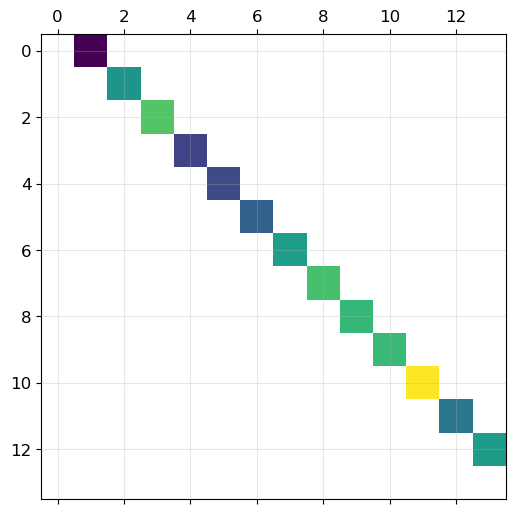

In [17]:
from matplotlib.colors import LogNorm
plt.matshow(S.T, cmap='viridis', norm=LogNorm()) ;

### Time scales

The enormous range of decay rates (spanning ~23 orders of magnitude) means we need to be thoughtful about which time window we examine. We'll focus on a few geologically interesting regimes.

In [18]:
print("Time scale survey:")
print(f"  Fastest decay: {half_lives.min():.4g} yr  ({half_lives.min()/MICROSECOND:.1f} µs) — ²¹⁴Po")
print(f"  Slowest decay: {half_lives.max():.4g} yr  ({half_lives.max()/1e9:.3f} Gyr) — ²³⁸U")
print(f"  Ratio: {half_lives.max() / half_lives.min():.2e}")
print()
print("Condition number of S:", np.linalg.cond(S))
print("(This is why direct Bateman equations are numerically treacherous!)")

Time scale survey:
  Fastest decay: 5.206e-12 yr  (164.3 µs) — ²¹⁴Po
  Slowest decay: 4.468e+09 yr  (4.468 Gyr) — ²³⁸U
  Ratio: 8.58e+20

Condition number of S: 1.2136530919163618e+21
(This is why direct Bateman equations are numerically treacherous!)


### Computing state occupancies via matrix exponential

We compute $\mathbf{p}(t) = \boldsymbol{\pi} \, e^{\mathbf{S}t}$ using `scipy.linalg.expm`, which uses Padé approximation with scaling and squaring.

In [19]:
def state_occupancies(S, pi, times):
    """Compute p(t) = pi @ expm(S * t) for each t in times."""
    n = len(pi)
    P = np.zeros((len(times), n))
    for i, t in enumerate(times):
        P[i] = pi @ expm(S * t)
    return P

def absorption_prob(S, pi, times):
    """Compute probability of being in absorbing state at each t."""
    P = state_occupancies(S, pi, times)
    return 1.0 - P.sum(axis=1)

In [20]:
states = np.zeros((n, n), dtype=int)
np.fill_diagonal(states, 1)
states

array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

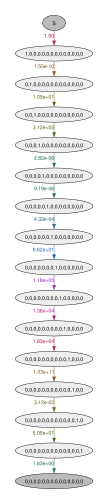

In [21]:
graph = Graph.from_matrices(ipv=[1]+[0]* (n - 1), sim=S.T, states=states)
graph.plot(rankdir='TB', ranksep=0.5)

In [ ]:
#t = np.logspace(-6, 10, 100)  # from microseconds to tens of billions of years
t = np.linspace(0.0001, 1, 100)

graph.pdf(t, granularity=9999099)

RuntimeError: Expected vertex with index 11 (state 0 0 0 0 0 0 0 0 0 0 1 0 0 0) to have outgoing rate divided by granularity <= 1. Rate is '133134884864.000000' ('1331.480713'). Increase the granularity


In [ ]:

for rewards in states.T:
    revt_graph = graph.reward_transform(rewards)
    plt.plot(t, revt_graph.pdf(t))
    break
plt.show()

In [ ]:
graph.expected_sojourn_time()

### Geological timescale: full chain evolution

We first look at the chain over billions of years — the timescale on which ${}^{238}\text{U}$ decays and ${}^{206}\text{Pb}$ accumulates. At this timescale, all intermediate isotopes are in **secular equilibrium** (their activities equal that of the parent).

In [ ]:
# Geological timescale: 0 to 10 billion years
t_geo = np.linspace(0, 10e9, 2000)
P_geo = state_occupancies(S, pi, t_geo)
Pb206 = absorption_prob(S, pi, t_geo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: U-238 and Pb-206
ax1.plot(t_geo / 1e9, P_geo[:, 0], 'b-', lw=2, label=r'$^{238}$U')
ax1.plot(t_geo / 1e9, Pb206, 'r-', lw=2, label=r'$^{206}$Pb (absorbing)')
ax1.axvline(4.468, color='gray', ls='--', alpha=0.5, label=r'$t_{1/2}$ of $^{238}$U')
ax1.set_xlabel('Time (Gyr)')
ax1.set_ylabel('Fraction of atoms')
ax1.set_title('Parent and stable daughter')
ax1.legend()

# Right: long-lived intermediates
long_lived = [3, 4, 5, 11]  # ²³⁴U, ²³⁰Th, ²²⁶Ra, ²¹⁰Pb
for idx in long_lived:
    ax2.plot(t_geo / 1e9, P_geo[:, idx], lw=1.5, label=names[idx])

ax2.set_xlabel('Time (Gyr)')
ax2.set_ylabel('Fraction of atoms')
ax2.set_title('Long-lived intermediate isotopes')
ax2.legend()

plt.tight_layout()
plt.show()

print("Note: intermediate fractions are tiny because their half-lives are")
print("much shorter than ²³⁸U — they reach secular equilibrium almost instantly.")

### Shorter timescale: Ingrowth of ${}^{234}\text{Th}$ and ${}^{234}\text{Pa}$

If we start with pure ${}^{238}\text{U}$ and zoom into the first ~6 months, we can watch the short-lived daughters ${}^{234}\text{Th}$ ($t_{1/2} = 24.1$ d) and ${}^{234}\text{Pa}$ ($t_{1/2} = 1.17$ min) grow in toward secular equilibrium.

In [ ]:
# Zoom: first 200 days
t_short = np.linspace(0, 200 * DAY, 2000)
P_short = state_occupancies(S, pi, t_short)

fig, ax = plt.subplots(figsize=(12, 5))

# Normalize to secular equilibrium values for better visualization
# At secular equilibrium: N_i / N_1 = λ_1 / λ_i
for idx in [1, 2]:  # ²³⁴Th, ²³⁴Pa
    eq_ratio = lambdas[0] / lambdas[idx]
    ax.plot(t_short / DAY, P_short[:, idx] / eq_ratio, lw=2, label=names[idx])

ax.axhline(1.0, color='gray', ls='--', alpha=0.5, label='Secular equilibrium')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Fraction of secular equilibrium activity')
ax.set_title('Ingrowth of short-lived daughters (normalized to equilibrium)')
ax.legend()
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

print(f"Secular equilibrium ratio N(²³⁴Th)/N(²³⁸U) = λ₁/λ₂ = {lambdas[0]/lambdas[1]:.4e}")
print(f"Secular equilibrium ratio N(²³⁴Pa)/N(²³⁸U) = λ₁/λ₃ = {lambdas[0]/lambdas[2]:.4e}")

### Verification: Bateman equations vs matrix exponential

We verify our matrix exponential against the analytical Bateman solution for the first few isotopes in the chain.

In [ ]:
def bateman(lambdas_sub, t, N0=1.0):
    """
    Bateman equation for a linear decay chain.
    
    lambdas_sub: decay constants [λ_1, ..., λ_m] for the first m isotopes
    Returns N_m(t) / N_1(0)
    """
    m = len(lambdas_sub)
    result = 0.0
    prod_lambdas = np.prod(lambdas_sub[:-1])  # product of λ_1 ... λ_{m-1}
    
    for j in range(m):
        denom = 1.0
        for k in range(m):
            if k != j:
                denom *= (lambdas_sub[k] - lambdas_sub[j])
        result += np.exp(-lambdas_sub[j] * t) / denom
    
    return N0 * prod_lambdas * result


# Compare for ²³⁴U (state 3, using first 4 decay constants)
# Use a timescale where ²³⁴U has appreciable abundance
t_test = np.linspace(1e3, 2e6, 500)
P_test = state_occupancies(S, pi, t_test)

# Bateman for state index 3 (4th isotope)
N_bateman = np.array([bateman(lambdas[:4], t) for t in t_test])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[3, 1])

ax1.plot(t_test / 1e3, P_test[:, 3], 'b-', lw=2, label='Matrix exponential')
ax1.plot(t_test / 1e3, N_bateman, 'r--', lw=2, label='Bateman equation')
ax1.set_ylabel(r'$N(^{234}$U$) / N_0$')
ax1.set_title(r'Verification: $^{234}$U abundance')
ax1.legend()

# Relative error
rel_err = np.abs(P_test[:, 3] - N_bateman) / np.maximum(np.abs(N_bateman), 1e-300)
ax2.semilogy(t_test / 1e3, rel_err, 'k-', lw=1)
ax2.set_xlabel('Time (kyr)')
ax2.set_ylabel('Relative error')
ax2.set_title('Relative difference between methods')

plt.tight_layout()
plt.show()

### The absorption time density

The density of the phase-type distribution $f(t) = \boldsymbol{\pi} e^{\mathbf{S}t} \mathbf{s}$ gives the rate at which atoms arrive at the stable ${}^{206}\text{Pb}$ state. This is equivalent to the **activity** of the last unstable isotope ${}^{210}\text{Po}$.

In [ ]:
t_abs = np.linspace(1e7, 10e9, 2000)
P_abs = state_occupancies(S, pi, t_abs)
f_t = P_abs @ s  # absorption density

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_abs / 1e9, f_t * 1e9, 'purple', lw=2)  # scale to per-Gyr
ax.set_xlabel('Time (Gyr)')
ax.set_ylabel(r'$f(t)$ (Gyr$^{-1}$)')
ax.set_title(r'Absorption time density: rate of $^{206}$Pb production')
ax.fill_between(t_abs / 1e9, f_t * 1e9, alpha=0.2, color='purple')

plt.tight_layout()
plt.show()

# Mean absorption time
# For PH(pi, S): E[T] = -pi @ S^{-1} @ 1
mean_time = -pi @ np.linalg.solve(S, np.ones(n))
print(f"Mean time to reach ²⁰⁶Pb: {mean_time/1e9:.3f} Gyr")
print(f"(Compare: mean of exponential with λ of ²³⁸U = {1/lambdas[0]/1e9:.3f} Gyr)")
print(f"The mean is dominated by the slowest step, as expected.")

### Summary of the phase-type representation

The uranium-238 decay chain is a textbook Coxian phase-type distribution (sequential states, no skipping). Key properties:

| Property | Value |
|----------|-------|
| Number of transient states | 14 |
| Absorbing state | ${}^{206}\text{Pb}$ |
| Structure of $\mathbf{S}$ | Lower bidiagonal (irreversible) |
| Mean absorption time | $\approx 1/\lambda_1$ (bottleneck) |
| Numerical challenge | Condition number $\sim 10^{23}$ |

The matrix exponential formulation is elegant precisely because it wraps up the Bateman equations into a single object $e^{\mathbf{S}t}$ — and generalizes trivially to branching chains, reversible reactions, and non-sequential topologies.